

# Segmental parameters for obese
A system of axes has been defined for each segment, with an origin at the segment mass center, while axes have been aligned with approximate body axes: anteroposterior (x), vertical (y), and mediolateral (z). The corresponding result for the position of the mass center for the head and hand is measured at the center and the center of mass for the thigh is measured from the upper cross section of the thigh lower part, The other segments are measured from the upper cross section of each segment. The measurements are taken with positive values indicating anterior (forward), upward, and lateral (sideways) directions.

![fig1_method 4.png](<attachment:fig1_method 4.png>)

Head+Neck (Ellipsoid)

Upper torso (Frustum of elliptical cone)

Middle torso (Frustum elliptical cone)

Lower torso (Frustum of elliptical cone + elliptical cone)

Thigh  (Biased elliptical cone + Frustum of elliptical cone) 

Shank (Frustum of elliptical cone)

Foot (Frustum of elliptical cone)

Upper arm (Frustum of elliptical cone)

Lower arm (Frustum of elliptical cone)

Hand (Ellipsoid)

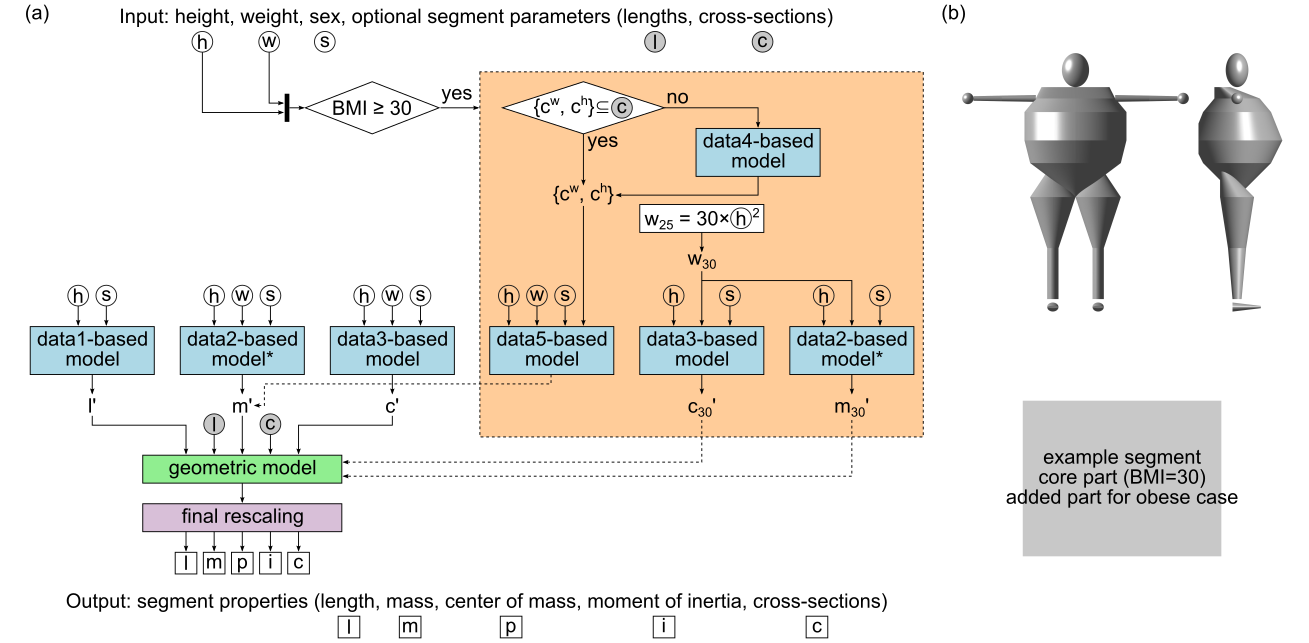

In [657]:
# Import Necessary Modules
import glob
import matplotlib.pyplot as plt 
from skimage import io
import numpy as np
import math
%matplotlib inline 

Parameters from ML

## 1. Head+Neck (Ellipsoid)



Input parameters: Head_length, head_circumference_base, head_circumference_obese, head_mass

In [658]:
head_circumference_base=57.33
head_length=24.29305825

head_mass_base = 5.070034541
head_mass_obese = 6.070034541
head_circumference_obese=head_circumference_base*(head_mass_obese/head_mass_base)

Mass, COM, and MOI for Head

In [659]:

def ellipsoid_inertia(R, r, h, m):
    Ixx = (1/5) * m * (R**2 + h**2)
    Iyy = (1/5) * m * (r**2 + R**2)
    Izz = (1/5) * m * (r**2 + h**2)
    return Ixx, Iyy, Izz

In [660]:

# Ellipsoid parameters for head and neck
r = head_circumference_obese/(2 * np.pi) # Head circumference
R = head_circumference_obese/(2 * np.pi) # Head circumference
h = head_length/2 # Head length

m = head_mass_obese 
# Center of mass of ellipsoid (at the center)
center_of_mass_head_obese_Y =  0
center_of_mass_head_obese_X =  0
center_of_mass_head_obese_Z =  0

# Inertia of ellipsoid
Ixx_head_obese, Iyy_head_obese, Izz_head_obese = ellipsoid_inertia(r, R, h, m)

print(f"Head and Neck - Mass: {head_mass_obese:.2f}, Center of Mass(X): {center_of_mass_head_obese_X:.2f}, Center of Mass(Y): {center_of_mass_head_obese_Y:.2f}, Center of Mass(Z): {center_of_mass_head_obese_Z:.2f}, (Ixx: {Ixx_head_obese:.2f}, Iyy: {Iyy_head_obese:.2f}, Izz: {Izz_head_obese:.2f})")


Head and Neck - Mass: 6.07, Center of Mass(X): 0.00, Center of Mass(Y): 0.00, Center of Mass(Z): 0.00, (Ixx: 323.98, Iyy: 289.74, Izz: 323.98)


In [661]:
import numpy as np

def calculate_depth_breath(bmi, depth_30, breath_30, circumference):
    if bmi <= 30:
        return depth_30, breath_30
    elif bmi >= 40:
        # At BMI 40, depth and breath are equal (ratio is 1)
        depth_40 = breath_40 = circumference / np.pi
        return depth_40, breath_40
    else:
        # Linear interpolation between BMI 30 and 40
        t = (bmi - 30) / 10  # t goes from 0 to 1 as BMI goes from 30 to 40
        
        # Calculate circumference at BMI 30 using the ellipse formula
        a_30, b_30 = depth_30/2, breath_30/2  # Convert diameters to radii
        h_30 = ((a_30 - b_30) / (a_30 + b_30))**2
        circumference_30 = np.pi * (a_30 + b_30) * (1 + 3*h_30 / (10 + np.sqrt(4 - 3*h_30)))
        
        # Calculate depth and breath at BMI 40
        depth_40 = breath_40 = circumference / np.pi
        
        # Interpolate depth and breath
        depth = depth_30 * (1 - t) + depth_40 * t
        breath = breath_30 * (1 - t) + breath_40 * t
        
        return depth, breath

## Torso mass distribution based on voulume change
Input parameters for base model: Neckbase_circumference, Shoulder_breadth, Chest_depth, Chest_breadth, upper_torso_mass, upper_torso (length), middle_torso (length), shoulderwaistlen (length), Waist_circumference, Waist_depth, Waist_breadth, Hip_breadth, buttock_depth, lower_torso_mass, crotch_height, thigh (length), shank (length), ankle_height (length) 

Input parameters for obese model: Shoulder_breadth, Chest_circumference, Waist_circumference, Hip_circumference

# Upper Torso Volume 

Upper Torso Volume (Frustum of right elliptical cone + Reverted Frustum of right elliptical cone) for base model


Input parameters: Neckbase_circumference, Shoulder_breadth, Chest_depth, Chest_breadth, upper_torso_mass, upper_torso (length), middle_torso (length), shoulderwaistlen (length)



Upper Torso Volume (Frustum of right elliptical cone + Reverted Frustum of right elliptical cone) for obese model

Input parameters for obese model: Shoulder_breadth, Chest_circumference, Waist_circumference

In [662]:
BMI_obese = 39
torso_mass_obese = 58

# Base parameters for upper torso
Neckbase_circumference_base = 42.56051158
Shoulder_breadth_base = 41.58
Chest_depth_base = 23.94
upper_torso_length = 23.1068407
middle_torso_length = 23.62299232
shoulderwaistlen = 38.41019798
Chest_breadth_base = 28.50779903
uppertorso_mass_base = 15.6765

# Obese parameters for upper torso
Waist_circumference_obese = 115.1
Waist_circumference_base= 87.80767873
Neckbase_circumference_obese = Neckbase_circumference_base * (Waist_circumference_obese / Waist_circumference_base)
Shoulder_breadth_obese = 41.06960979
Chest_circumference_obese = 129.1271329
Chest_depth_obese, Chest_breadth_obese = calculate_depth_breath(BMI_obese, Chest_depth_base, Chest_breadth_base, Chest_circumference_obese)

# Middle Torso Volume 

Middle Torso Volume (Reverted Frustum of right elliptical cone) for base model

Input parameters: Chest_depth, Chest_breadth, Waist_depth, Waist_breadth, middle_torso (length)


Middle Torso Volume (Frustum of right cone or Reverted Frustum of right cone) for obese model

Input parameters for obese model: Chest_circumference, Waist_circumference, middle_torso (length)

In [663]:
# Middle torso base and obese calculations
middletorso_mass_base = 10.83378109
Waist_breadth_base = 30.96304633
Waist_depth_base = 21.82
Waist_circumference_obese = 115.1
Waist_depth_obese, Waist_breadth_obese = calculate_depth_breath(BMI_obese, Waist_depth_base, Waist_breadth_base, Waist_circumference_obese)


# Lower  Torso  Volume


( Frustum of right elliptical cone only+ right elliptical cone)

Lower  Torso  Volume for base model

Input parameters: Waist_depth, Waist_breadth, Hip_breadth, buttock_depth, lower_torso_mass, crotch_height, thigh (length), shank (length), ankle_height (length)

Lower  Torso  Volume for obese model

Input parameters: Waist_depth, Waist_breadth, Hip_breadth, buttock_depth, lower_torso_mass, crotch_height, thigh (length), shank (length), ankle_height (length), Waist_circumference_obese, Hip_circumference_obese

In [664]:
# Lower torso base and obese calculations
lowertorso_mass_base = 11.31499083
lowertorso_length = 16.75644663
thigh_length  = 41.89445507 #cm
shank_length  = 42.89212065 #cm
ankle_height = 7.434086377  #cm
crotch_height= 87.32 
Hip_circumference_obese =100
Hip_breadth_base= 33.75483608
Hip_depth_base= 23.15
crotch = (ankle_height+shank_length+thigh_length)-crotch_height 

Hip_depth_obese, Hip_breadth_obese = calculate_depth_breath(BMI_obese, Hip_depth_base, Hip_breadth_base, Hip_circumference_obese)

#Torso Mass for Obese

In [665]:
import numpy as np


def calculate_segment_mass_changes(base_volumes, obese_volumes, base_masses, total_mass_change):
    """Distribute mass changes proportionally based on volume changes."""
    total_volume_change = sum(obese_volumes) - sum(base_volumes)
    mass_changes = [
        base_mass + total_mass_change * ((obese_volume - base_volume) / total_volume_change)
        for base_volume, obese_volume, base_mass in zip(base_volumes, obese_volumes, base_masses)
    ]
    return mass_changes

# Base parameters for upper torso (upper part)

R1 = Neckbase_circumference_base / (2 * np.pi)
r1 = R1
R2 = Shoulder_breadth_base / 2
r2 = Chest_depth_base / 2
h1 = upper_torso_length + middle_torso_length - shoulderwaistlen

# Upper torso upper part volume
volume_uppertorso_upper_base = (1 / 3) * np.pi * h1 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))

# Base parameters for upper torso (lower part)
R1 = Shoulder_breadth_base / 2
r1 = Chest_depth_base / 2
R2 = Chest_breadth_base / 2
r2 = Chest_depth_base / 2
h2 = shoulderwaistlen - middle_torso_length

# Upper torso lower part volume
volume_uppertorso_lower_base = (1 / 3) * np.pi * h2 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
volume_uppertorso_base = volume_uppertorso_upper_base + volume_uppertorso_lower_base


# Obese parameters for upper torso

Neckbase_circumference_obese = Neckbase_circumference_base * (Waist_circumference_obese / Waist_circumference_base)
Chest_depth_obese, Chest_breadth_obese = calculate_depth_breath(BMI_obese, Chest_depth_base, Chest_breadth_base, Chest_circumference_obese)

R1 = Neckbase_circumference_obese / (2 * np.pi)
r1 = R1
R2 = Shoulder_breadth_obese / 2
r2 = Chest_depth_base / 2
volume_uppertorso_upper_obese = (1 / 3) * np.pi * h1 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))

R1 = Shoulder_breadth_obese / 2
r1 = Chest_depth_base / 2
R2 = Chest_breadth_obese / 2
r2 = Chest_depth_obese / 2
volume_uppertorso_lower_obese = (1 / 3) * np.pi * h2 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
volume_uppertorso_obese = volume_uppertorso_upper_obese + volume_uppertorso_lower_obese

# Middle torso base and obese calculations
h3 = middle_torso_length

R1 = Chest_breadth_base / 2
r1 = Chest_depth_base / 2
R2 = Waist_breadth_base / 2
r2 = Waist_depth_base / 2
volume_middletorso_base = (1 / 3) * np.pi * h3 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))


Chest_depth_obese, Chest_breadth_obese = calculate_depth_breath(BMI_obese, Chest_depth_base, Chest_breadth_base, Chest_circumference_obese)
Waist_depth_obese, Waist_breadth_obese = calculate_depth_breath(BMI_obese, Waist_depth_base, Waist_breadth_base, Waist_circumference_obese)

R1, r1 = Chest_breadth_obese / 2, Chest_depth_obese / 2
R2, r2 = Waist_breadth_obese / 2, Waist_depth_obese / 2
volume_middletorso_obese = (1 / 3) * np.pi * h3 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))

# Lower torso base and obese calculations

h4 = lowertorso_length
h5 = crotch

R1 = Waist_breadth_base / 2
r1 = Waist_depth_base / 2
R2 = Hip_breadth_base / 2
r2 = Hip_depth_base / 2
volume_lowertorso_base_upper = (1 / 3) * np.pi * h4 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
volume_lowertorso_base_lower = (np.pi * R2 * r2 * h5) / 3
volume_lowertorso_base = volume_lowertorso_base_upper + volume_lowertorso_base_lower

Waist_depth_obese, Waist_breadth_obese = calculate_depth_breath(BMI_obese, Waist_depth_base, Waist_breadth_base, Waist_circumference_obese)
Hip_depth_obese, Hip_breadth_obese = calculate_depth_breath(BMI_obese, Hip_depth_base, Hip_breadth_base, Hip_circumference_obese)
R1, r1 = Waist_breadth_obese / 2, Waist_depth_obese / 2
R2, r2 = Hip_breadth_obese / 2, Hip_depth_obese / 2

volume_lowertorso_obese_upper = (1 / 3) * np.pi * h4 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
volume_lowertorso_obese_lower = (np.pi * R2 * r2 * h5) / 3
volume_lowertorso_obese = volume_lowertorso_obese_upper + volume_lowertorso_obese_lower


base_volumes = [volume_uppertorso_base, volume_middletorso_base, volume_lowertorso_base]
obese_volumes = [volume_uppertorso_obese, volume_middletorso_obese, volume_lowertorso_obese]
base_masses = [uppertorso_mass_base, middletorso_mass_base, lowertorso_mass_base]
torso_mass_base = uppertorso_mass_base + middletorso_mass_base + lowertorso_mass_base
total_mass_change = torso_mass_obese - torso_mass_base
uppertorso_mass_obese, middletorso_mass_obese, lowertorso_mass_obese = calculate_segment_mass_changes(base_volumes, obese_volumes, base_masses, total_mass_change)

print(f"Uppertorso Mass (Obese): {uppertorso_mass_obese:.2f} kg")
print(f"Middletorso Mass (Obese): {middletorso_mass_obese:.2f} kg")
print(f"Lowertorso Mass (Obese): {lowertorso_mass_obese:.2f} kg")
print(f"Total Torso Mass (Obese): {torso_mass_obese:.2f} kg")


Uppertorso Mass (Obese): 20.20 kg
Middletorso Mass (Obese): 21.98 kg
Lowertorso Mass (Obese): 15.82 kg
Total Torso Mass (Obese): 58.00 kg


# Formula for COM, Moment of inertia of frustum of elliptical cone and elliptical cone

In [666]:
import numpy as np

def calculate_axes (circumference, diameter):
        """Calculate the semi-major and semi-minor axes from circumference and one axis diameter."""
        semi_major_axis = diameter / 2
        semi_minor_axis = (circumference / (2 * math.pi))**2 - semi_major_axis**2
        semi_minor_axis = math.sqrt(semi_minor_axis) if semi_minor_axis > 0 else semi_major_axis
        return semi_major_axis, semi_minor_axis

def calculate_center_of_mass(h, r1, R1, r2, R2):
    # Calculate the center of mass using the given formula
    center_of_mass = (h * (r1 * (R1 + R2) + r2 * (R1 + 3 * R2))) / (2 * (r1 * (2 * R1 + R2) + r2 * (R1 + 2 * R2)))
    return center_of_mass


def frustum_inertia(r1, R1, r2, R2, density, h):
    """
    Calculate the moments of inertia for a frustum of a right elliptical cone.
    
    Parameters:
    r1 (float): Semi-minor axis of the upper base ellipse
    R1 (float): Semi-major axis of the upper base ellipse
    r2 (float): Semi-minor axis of the lower base ellipse
    R2 (float): Semi-major axis of the lower base ellipse
    density (float): Density of the material
    h (float): Height of the frustum
    
    Returns:
    tuple: (Ixx, Iyy, Izz) moments of inertia for the frustum
    """
    volume = (1/3) * np.pi * h * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
    M = volume*density 
    Ixx= (np.pi / 240) * density * h * (
            4*h**2 * (r1*(2*R1 + 3*R2) + 3*r2*(R1 + 4*R2)) + 
            3 * (r1 * (4*R1**3 + 3*R1**2*R2 + 2*R1*R2**2 + R2**3) + 
                 r2 * (R1**3 + 2*R1**2*R2 + 3*R1*R2**2 + 4*R2**3))) 
        

    Iyy = (np.pi / 80) * density * h * (
            r1**3 * (4*R1 + R2) + r1**2 * r2 * (3*R1 + 2*R2) + 
            r1 * (4*R1**3 + 3*R1**2*R2 + 3*r2**2*R2 + R2**3 + 2*R1*(r2**2 + R2**2)) + 
            r2 * (R1**3 + 2*R1**2*R2 + 4*R2*(r2**2 + R2**2) + R1*(r2**2 + 3*R2**2)))

    Izz = (np.pi / 240) * density * h * (4*h**2 * (r1*(2*R1 + 3*R2) + 3*r2*(R1 + 4*R2)) + 
                                       3 * (r1**3 * (4*R1 + R2) + r1**2 * r2 * (3*R1 + 2*R2) + 
                                            r1 * r2**2 * (2*R1 + 3*R2) + r2**3 * (R1 + 4*R2))) 

    com = (h * (r1 * (R1 + R2) + r2 * (R1 + 3 * R2))) / (2 * (r1 * (2 * R1 + R2) + r2 * (R1 + 2 * R2)))   
    Ixx= Ixx-(M*com**2)
    Izz= Izz-(M*com**2)

    return Ixx, Iyy, Izz

def elliptical_cone_inertia(R1, r1, h, m):
    
    Ixx = (3 * m / 20) * (4 * R1**2 + h**2)
    Iyy = (3 * m / 10) * (r1**2 + R1**2)
    Izz = (3 * m / 20) * (4 * r1**2 + h**2)
    com = (1/4) *h
    Ixx= Ixx-(m*com**2)
    Izz= Izz-(m*com**2)
    return Ixx, Iyy, Izz


Combine_segments using Parallel Axis Theorem

In [667]:
import numpy as np

def combine_segments(segment1, segment2):
    """
    Combine two segments using mass, center of mass (COM), and inertia properties.
    Implements the Parallel Axis Theorem for adjusting inertia when the COM is shifted.

    Parameters:
    - segment1 (dict): Properties of the first segment (mass, COM, inertia tensor).
    - segment2 (dict): Properties of the second segment (mass, COM, inertia tensor).

    Returns:
    - dict: Combined segment properties (mass, COM, inertia tensor).
    """
    # Calculate the mass of the resulting segment
    combined_mass = segment1['mass'] +  segment2['mass']
    
    if combined_mass == 0:
        raise ValueError("Combined mass is zero, division by zero in COM calculation.")

    # Calculate the center of mass (COM) of the resulting segment
    r1 = np.array(segment1['com'])  # Original COM for segment 1
    r2 = np.array(segment2['com'])  # Original COM for segment 2
    combined_com = (segment1['mass'] * r1 + segment2['mass'] * r2) / combined_mass

    # Calculate the moments of inertia of the resulting segment
    I1 = np.array(segment1['inertia'])  # Inertia tensor for segment 1
    I2 = np.array(segment2['inertia'])  # Inertia tensor for segment 2

    # Compute relative position of COM for each segment
    r1_relative = r1 - combined_com
    r2_relative = r2 - combined_com
    # Apply the Parallel Axis Theorem to X and Z components only
    I_combined = np.zeros((3, 3))
    # X-component
    I_combined[0, 0] = (
        I1[0, 0] + I2[0, 0] + segment1['mass'] * (r1_relative[1]**2) + segment2['mass'] * (r2_relative[1]**2) + segment1['mass'] * (r1_relative[2]**2) + segment2['mass'] * (r2_relative[2]**2)
    )  
    # Y-component
    I_combined[1, 1] = (
        I1[1, 1] + I2[1, 1] + segment1['mass'] * (r1_relative[0]**2) + segment2['mass'] * (r2_relative[0]**2) + segment1['mass'] * (r1_relative[2]**2) + segment2['mass'] * (r2_relative[2]**2)
    )  
    # Z-component
    I_combined[2, 2] = (
        I1[2, 2] + I2[2, 2] + segment1['mass'] * (r1_relative[0]**2) + segment2['mass'] * (r2_relative[0]**2) + segment1['mass'] * (r1_relative[1]**2) + segment2['mass'] * (r2_relative[1]**2)
    ) 
   


    # Check for negative moments of inertia and issue a warning
    if np.any(I_combined < 0):
        print("Warning: Negative moments of inertia detected. Results may be physically implausible.")
        # Optional: Clamp negative values to zero
        I_combined[I_combined < 0] = 0

    # Return the combined segment properties
    return {
        'mass': combined_mass,
        'com': combined_com,
        'inertia': I_combined
        
    }



# Upper Torso: Mass, center_of_mass, Ixx_upper , Iyy_upper , Izz_upper 

In [668]:

#density=0.00087  #from Pearsall et al. (1996)
# R1= Neckbase radius semi_major_axis  
# r1= Neckbase  radius semi_minor_axis 
R1 = Neckbase_circumference_obese/(2 * np.pi) # Neck radius
r1 = Neckbase_circumference_obese/(2 * np.pi) # Neck radius

#R2, r2 = Shoulder_breadth, Chest_depth
R2, r2 = Shoulder_breadth_obese/2, Chest_depth_base/2 #instead of hest_depth_obese/2 

density= uppertorso_mass_obese/volume_uppertorso_obese
h1 = upper_torso_length + middle_torso_length - shoulderwaistlen # height

center_of_mass_upper1 = calculate_center_of_mass(h1, r1, R1, r2, R2)


m1=  uppertorso_mass_obese* (volume_uppertorso_upper_obese/volume_uppertorso_obese)
m2=  uppertorso_mass_obese* (volume_uppertorso_lower_obese/volume_uppertorso_obese)


Ixx_uppertorso_upper , Iyy_uppertorso_upper , Izz_uppertorso_upper  = frustum_inertia(r1, R1, r2, R2, density, h1)

Chest_depth_obese, Chest_breadth_obese= calculate_depth_breath(BMI_obese, Chest_depth_base, Chest_breadth_base, Chest_circumference_obese)

# Parameters for upper torso (lower part)
#R1, r1 = Shoulder_breadth, Chest_depth
R1, r1 = Shoulder_breadth_obese/2, Chest_depth_base/2 #instead of chest_depth_obese/2 
#R2, r2 = Chest_breadth, Chest_depth
R2, r2 = Chest_breadth_obese/2, Chest_depth_obese/2
h2 =  shoulderwaistlen-middle_torso_length # height

center_of_mass_upper2 =calculate_center_of_mass(h2, r1, R1, r2, R2)

# Inertia calculations 

Ixx_uppertorso_lower , Iyy_uppertorso_lower , Izz_uppertorso_lower  = frustum_inertia(r1, R1, r2, R2, density, h2)


# Combined Inertia Properties (neck base~chest)
com_y_upper= center_of_mass_upper1
com_y_lower= h1+center_of_mass_upper2


segment1 = {
    'mass': m1,
    'com': [0.0, com_y_upper , 0.0],
    'inertia': [[Ixx_uppertorso_upper, 0.0, 0.0], [0.0, Iyy_uppertorso_upper, 0.0], [0.0, 0.0, Izz_uppertorso_upper]]
}

segment2 = {
    'mass': m2,
    'com': [0.0, com_y_lower , 0.0],
    'inertia': [[Ixx_uppertorso_lower, 0.0, 0.0], [0.0, Iyy_uppertorso_lower, 0.0], [0.0, 0.0, Izz_uppertorso_lower]]
}

result = combine_segments(segment1, segment2)

uppertorso_mass_obese = result['mass']
center_of_mass_uppertorso_obese_X = result['com'][0]
center_of_mass_uppertorso_obese_Y = result['com'][1]
center_of_mass_uppertorso_obese_Z = result['com'][2]
Ixx_uppertorso_obese = result['inertia'][0, 0]
Iyy_uppertorso_obese = result['inertia'][1, 1]
Izz_uppertorso_obese = result['inertia'][2, 2]

# Print the formatted results
print(f"Upper Torso -  Mass: {uppertorso_mass_obese:.2f}, "
      f"Center of Mass(X): {center_of_mass_uppertorso_obese_X:.2f}, "
      f"Center of Mass(Y): -{center_of_mass_uppertorso_obese_Y:.2f}, "
      f"Center of Mass(Z): {center_of_mass_uppertorso_obese_Z:.2f}, "
      f"Inertia: (Ixx: {Ixx_uppertorso_obese:.2f}, "
      f"Iyy: {Iyy_uppertorso_obese:.2f}, "
      f"Izz: {Izz_uppertorso_obese:.2f})")


Upper Torso -  Mass: 20.20, Center of Mass(X): 0.00, Center of Mass(Y): -13.82, Center of Mass(Z): 0.00, Inertia: (Ixx: 2684.92, Iyy: 3108.07, Izz: 1953.20)


# Middle Torso: center_of_mass, Ixx_middle , Iyy_middle , Izz_middle 

In [669]:
# Parameters for middle torso 

#R1, r1 = Chest_breadth, Chest_depth
R1, r1 = Chest_breadth_obese/2, Chest_depth_obese/2 
#R2, r2 = Waist_breadth, Waist_depth
R2, r2 = Waist_breadth_obese/2, Waist_depth_obese/2

h =middle_torso_length
density= middletorso_mass_obese/volume_middletorso_obese
# Center of mass of middle torso (3)

center_of_mass_middletorso_obese = calculate_center_of_mass(h, r1, R1, r2, R2)
center_of_mass_middletorso_obese_Y= center_of_mass_middletorso_obese 
center_of_mass_middletorso_obese_Z= 0

# Inertia calculations based on formulas
Ixx_middletorso_obese , Iyy_middletorso_obese, Izz_middletorso_obese  = frustum_inertia(r1, R1, r2, R2, density, h)


# In case of chest_depth is larger than waist_depth 
if r1 > r2:
    volume_middletorso_obese_posterior = (np.pi * R1 * r2) * h # Volume of elliptical cylinder
    volume_middletorso_obese_anterior = volume_middletorso_obese - volume_middletorso_obese_posterior
    com1_x =  (2*r1 - 2*r2) * (1/3)+2*r2 # com of Volume of elliptical halfcone
    com2_x =  r2
    com_x = (volume_middletorso_obese_anterior * com1_x + volume_middletorso_obese_posterior * com2_x) / volume_middletorso_obese
    d_x = abs(com_x - r2)
else: # In case of waist_depth is larger than chest_depth 
    volume_middletorso_obese_posterior = (np.pi * R1 * r2) * h # Volume of elliptical cylinder
    volume_middletorso_obese_anterior = volume_middletorso_obese - volume_middletorso_obese_posterior
    com1_x = (2*r2 - 2*r1) * (1/3)+2*r1 # com of Volume of elliptical halfcone
    com2_x = r1
    com_x = (volume_middletorso_obese_anterior * com1_x + volume_middletorso_obese_posterior * com2_x) / volume_middletorso_obese
    d_x = abs(com_x - r1)
# use the principle of weighted averages, considering the volume and center of mass of each part    
center_of_mass_middletorso_obese_X= d_x      
# incorporate the principles of the parallel axis theorem to adjust the moments of inertia when the center of mass is shifted.
Izz_middletorso_obese += (middletorso_mass_obese * d_x**2 )
Iyy_middletorso_obese += (middletorso_mass_obese * d_x**2 )

print(f"Middle Torso -  Mass: {middletorso_mass_obese:.2f}, Center of Mass(X): {center_of_mass_middletorso_obese_X:.2f}, Center of Mass(Y): -{center_of_mass_middletorso_obese_Y:.2f}, Center of Mass(Z): {center_of_mass_middletorso_obese_Z:.2f}, Inertia: (Ixx: {Ixx_middletorso_obese:.2f}, Iyy: {Iyy_middletorso_obese:.2f}, Izz: {Izz_middletorso_obese:.2f})")

Middle Torso -  Mass: 21.98, Center of Mass(X): 0.20, Center of Mass(Y): -11.39, Center of Mass(Z): 0.00, Inertia: (Ixx: 3007.34, Iyy: 3907.36, Izz: 2938.53)


# Lower Torso: center_of_mass, Ixx_lower , Iyy_lower , Izz_lower

In [670]:
# Parameters for lower torso 
#R1, r1 = Waist_breadth, Waist_depth
R1, r1 = Waist_breadth_obese/2, Waist_depth_obese/2
#R2, r2 = Hip_breadth, buttock_depth
R2, r2 = Hip_breadth_obese/2, Hip_depth_obese/2

h4 = lowertorso_length
h5 = crotch

# Volume of elliptical frustum
volume_lowertorso_obese_upper = (1/3) * np.pi * h4 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))

# Volume of elliptical cone
volume_lowertorso_obese_lower =  (1/3) * (np.pi * R2 * r2 * h5) 
volume_lowertorso_obese= volume_lowertorso_obese_upper+volume_lowertorso_obese_lower 

m1=  lowertorso_mass_obese* (volume_lowertorso_obese_upper/volume_lowertorso_obese)
m2=  lowertorso_mass_obese* (volume_lowertorso_obese_lower/volume_lowertorso_obese)
density= lowertorso_mass_obese/volume_lowertorso_obese #density=0.00107, from Pearsall et al. (1996)


center_of_mass_lowertorso_upper = calculate_center_of_mass(h4, r1, R1, r2, R2)

# Inertia calculations formulas_upper

Ixx_lowertorso_upper, Iyy_lowertorso_upper, Izz_lowertorso_upper   = frustum_inertia(r1, R1, r2, R2, density, h4)


center_of_mass_lowertorso_lower = (h5)/4

# Inertia calculations formulas_lower

Ixx_lowertorso_lower, Iyy_lowertorso_lower, Izz_lowertorso_lower = elliptical_cone_inertia(R2, r2, h5, m2)


# Combined Inertia Properties (waist~crotch)

# In case of waist_depth is larger than buttock_depth 
if r1 > r2:
    volume_lowertorso_obese_upper_posterior = (np.pi * R1 * r2) * h4 # Volume of elliptical cylinder
    volume_lowertorso_obese_upper_anterior = volume_lowertorso_obese_upper - volume_lowertorso_obese_upper_posterior
    com1_x =  (2*r1 - 2*r2) * (1/3)+2*r2 # com of Volume of elliptical halfcone
    com2_x =  r2
    com_x_upper = (volume_lowertorso_obese_upper_anterior * com1_x + volume_lowertorso_obese_upper_posterior * com2_x) / volume_lowertorso_obese_upper
else: # In case of buttock_depth is larger than waist_depth 
    volume_lowertorso_obese_upper_posterior = (np.pi * R1 * r2) * h5 # Volume of elliptical cylinder
    volume_lowertorso_obese_upper_anterior = volume_lowertorso_obese_upper - volume_lowertorso_obese_upper_posterior
    com1_x = (2*r2 - 2*r1) * (1/3)+2*r1 # com of Volume of elliptical halfcone
    com2_x = r1
    com_x_upper = (volume_lowertorso_obese_upper_anterior * com1_x + volume_lowertorso_obese_upper_posterior * com2_x) / volume_lowertorso_obese_upper
# use the principle of weighted averages, considering the volume and center of mass of each part            

com_x_lower = r2


com_y_upper= center_of_mass_lowertorso_upper
com_y_lower= lowertorso_length+center_of_mass_lowertorso_lower


segment1 = {
    'mass': m1,
    'com': [com_x_upper, com_y_upper , 0.0],
    'inertia': [[Ixx_lowertorso_upper, 0.0, 0.0], [0.0, Iyy_lowertorso_upper, 0.0], [0.0, 0.0, Izz_lowertorso_upper]]
}

segment2 = {
    'mass': m2,
    'com': [com_x_lower, com_y_lower, 0.0],
    'inertia': [[Ixx_lowertorso_lower, 0.0, 0.0], [0.0, Iyy_lowertorso_lower, 0.0], [0.0, 0.0, Izz_lowertorso_lower]]
}


result = combine_segments(segment1, segment2)

lowertorso_mass_obese = result['mass']
center_of_mass_lowertorso_obese_X = result['com'][0] -r1
center_of_mass_lowertorso_obese_Y = result['com'][1]
center_of_mass_lowertorso_obese_Z = result['com'][2]
Ixx_lowertorso_obese = result['inertia'][0, 0]
Iyy_lowertorso_obese = result['inertia'][1, 1]
Izz_lowertorso_obese = result['inertia'][2, 2]

# Print the formatted results
print(f"Lower Torso -  Mass: {lowertorso_mass_obese:.2f}, "
      f"Center of Mass(X): {center_of_mass_lowertorso_obese_X:.2f}, "
      f"Center of Mass(Y): -{center_of_mass_lowertorso_obese_Y:.2f}, "
      f"Center of Mass(Z): {center_of_mass_lowertorso_obese_Z:.2f}, "
      f"Inertia: (Ixx: {Ixx_lowertorso_obese:.2f}, "
      f"Iyy: {Iyy_lowertorso_obese:.2f}, "
      f"Izz: {Izz_lowertorso_obese:.2f})")

Lower Torso -  Mass: 15.82, Center of Mass(X): -1.96, Center of Mass(Y): -8.82, Center of Mass(Z): 0.00, Inertia: (Ixx: 1710.01, Iyy: 2249.41, Izz: 1637.31)


# Leg mass distribution based on voulume change


# Thigh 

Input parameters for base model: thigh_circumference, calf_circumference, thigh (length), shank (length), ankle_height (length), crotch_height (length), Thigh_mass_base

In [671]:
# Frustum parameters for thigh
thigh_circumference_base = 59.4984303
calf_circumference_base = 38.11171942
ankle_circumference_base = 22.58078373

thigh_length = 41.89445507
shank_length = 42.89212065
ankle_height = 7.434086377  #cm

leg_mass_obese = 15.559
foot_mass_base = 0.929429937
thigh_mass_base = 9.30942572  # Thigh mass for base
shank_mass_base = 3.1445993   # Shank mass for base
leg_mass_base = foot_mass_base + shank_mass_base + thigh_mass_base

Input parameters for obese model: thigh_circumference, calf_circumference, thigh (length), shank (length), ankle_height (length), crotch_height (length)  

In [672]:
# Frustum parameters for thigh
thigh_circumference_obese = 58.00572135
calf_circumference_obese = 43.68945542
ankle_circumference_obese = 27.00944237

# Shank 

Input parameters for base model:  calf_circumference, ankle_circumference, shank (length), shank_mass_base

In [673]:

calf_circumference_base = 38.11171942
ankle_circumference_base = 22.58078373

shank_length = 42.89212065
shank_mass_base = 3.1445993   # Shank mass for base

Input parameters for obese model:  calf_circumference, ankle_circumference, shank (length)

In [674]:
# Example Inputs
calf_circumference_obese = 43.68945542
ankle_circumference_obese = 27.00944237

shank_length = 42.89212065


# Foot

In [675]:
# Frustum parameters for foot
foot_length  = 27.59313917 #cm
balloffoot_circumference = 25.12666045#cm
foot_mass= 0.929429937 #kg
foot_mass_obese=foot_mass

In [676]:
import numpy as np

def frustum_volume(r1, r2, h):
    """Calculate the volume of a frustum."""
    return (1 / 3) * np.pi * h * (r1**2 + r2**2 + r1 * r2)

def calculate_leg_mass(thigh_circumference_base, calf_circumference_base, ankle_circumference_base, thigh_circumference_obese, calf_circumference_obese, ankle_circumference_obese,thigh_length, shank_length, crotch, thigh_mass_base, shank_mass_base, foot_mass_base, leg_mass_base, leg_mass_obese):
    """Calculate the mass distribution of leg segments for base and obese conditions."""
    # Thigh volumes
    r1_thigh_base = thigh_circumference_base / (2 * np.pi)
    r2_thigh_base = calf_circumference_base / (2 * np.pi)
    h1_thigh = crotch
    h2_thigh = thigh_length - crotch

    volume_thigh_base_upper = (np.pi * r1_thigh_base**2 * h1_thigh) / 3
    volume_thigh_base_lower  = frustum_volume(r1_thigh_base, r2_thigh_base, h2_thigh)
    volume_thigh_base = volume_thigh_base_upper + volume_thigh_base_lower

    # Obese thigh volumes
    r1_thigh_obese = thigh_circumference_obese / (2 * np.pi)
    r2_thigh_obese = calf_circumference_obese / (2 * np.pi)

    volume_thigh_obese_upper = (np.pi * r1_thigh_obese**2 * h1_thigh) / 3
    volume_thigh_obese_lower = frustum_volume(r1_thigh_obese, r2_thigh_obese, h2_thigh)
    volume_thigh_obese = volume_thigh_obese_upper + volume_thigh_obese_lower
    # Volume change for thigh
    volumechange_thigh = volume_thigh_obese - volume_thigh_base

    # Shank volumes
    r1_shank_base = calf_circumference_base / (2 * np.pi)
    r2_shank_base = ankle_circumference_base / (2 * np.pi)

    volume_shank_base = frustum_volume(r1_shank_base, r2_shank_base, shank_length)

    # Obese shank volumes
    r1_shank_obese = calf_circumference_obese / (2 * np.pi)
    r2_shank_obese = ankle_circumference_obese / (2 * np.pi)

    volume_shank_obese = frustum_volume(r1_shank_obese, r2_shank_obese, shank_length)

    # Volume change for shank
    volumechange_shank = volume_shank_obese - volume_shank_base

    # Total volume and mass change
    Total_volumechange_leg = volumechange_thigh + volumechange_shank
    Total_masschange = leg_mass_obese - leg_mass_base


    # Distributing mass changes proportionally
   

    thigh_mass_obese = thigh_mass_base + Total_masschange * (volumechange_thigh / Total_volumechange_leg)
    shank_mass_obese = shank_mass_base + Total_masschange * (volumechange_shank / Total_volumechange_leg)
    foot_mass_obese = foot_mass_base

    # Final leg mass
    leg_mass_obese = thigh_mass_obese + shank_mass_obese + foot_mass_obese

    return thigh_mass_obese, shank_mass_obese, foot_mass_obese, leg_mass_obese


# Calculating leg mass for obese condition
thigh_mass_obese, shank_mass_obese, foot_mass_obese, leg_mass_obese = calculate_leg_mass(
    thigh_circumference_base, calf_circumference_base, ankle_circumference_base, thigh_circumference_obese, calf_circumference_obese, ankle_circumference_obese,thigh_length, shank_length, crotch, thigh_mass_base, shank_mass_base, foot_mass_base, leg_mass_base, leg_mass_obese
)

# Outputs
print(f"Thigh Mass (Obese): {thigh_mass_obese:.2f} kg")
print(f"Shank Mass (Obese): {shank_mass_obese:.2f} kg")
print(f"Foot Mass (Obese): {foot_mass_obese:.2f} kg")
print(f"Total Leg Mass (Obese): {leg_mass_obese:.2f} kg")


Thigh Mass (Obese): 9.99 kg
Shank Mass (Obese): 4.64 kg
Foot Mass (Obese): 0.93 kg
Total Leg Mass (Obese): 15.56 kg


# Thigh: Mass, center_of_mass, Ixx_thigh , Iyy_thigh , Izz_thigh 

In [677]:

# Frustum parameters for thigh
r1 =thigh_circumference_obese /(2 * np.pi)   # radius at one end
R1= r1
r2 =calf_circumference_obese /(2 * np.pi)  # radius at other end
R2= r2

h5=crotch # height

h6 = thigh_length-crotch   # height

# Volume of biased cone
volume_thigh_obese_upper =  (np.pi * (r1)**2 * h5) / 3
# Volume of frustum 
volume_thigh_obese_lower = (1/3) * np.pi * h6 * (r1**2 + r2**2 + r1*r2)
# Volume of half cone

volume_thigh_obese= volume_thigh_obese_upper+volume_thigh_obese_lower 
density=thigh_mass_obese/volume_thigh_obese

m1=  thigh_mass_obese* (volume_thigh_obese_upper/volume_thigh_obese)
m2=  thigh_mass_obese* (volume_thigh_obese_lower/volume_thigh_obese)


# Center of mass of  cone
center_of_mass_thigh_upper = h5*(3/4)

# Center of mass of frustum
center_of_mass_thigh_lower = calculate_center_of_mass(h6, r1, R1, r2, R2)
d1_z=(r1)*(0.25)

# Inertia of cone 
Ixx_thigh_upper , Iyy_thigh_upper , Izz_thigh_upper  = elliptical_cone_inertia(R1, r1, h5, m1)
Ixx_thigh_upper += (m1 * d1_z**2)
Iyy_thigh_upper += (m1 * d1_z**2)

# Inertia of frustum
Ixx_thigh_lower, Iyy_thigh_lower, Izz_thigh_lower = frustum_inertia(r1, R1, r2, R2, density, h6)

com_y_upper= center_of_mass_thigh_upper 
com_z_upper= (r1)*(0.25)+r1

com_y_lower= crotch+center_of_mass_thigh_lower 
com_z_lower= r1

# Combined Inertia Properties (crotch~knee)
segment1 = {
    'mass': m1,
    'com': [0.0, com_y_upper,com_z_upper],
    'inertia': [[Ixx_thigh_upper, 0.0, 0.0], [0.0, Iyy_thigh_upper, 0.0], [0.0, 0.0, Izz_thigh_upper]]
}

segment2 = {
    'mass': m2,
    'com': [0.0, com_y_lower, com_z_lower],
    'inertia': [[Ixx_thigh_lower, 0.0, 0.0], [0.0, Iyy_thigh_lower, 0.0], [0.0, 0.0, Izz_thigh_lower]]
}


result = combine_segments(segment1, segment2)

thigh_mass_obese = result['mass']
center_of_mass_thigh_obese_X = result['com'][0] 
center_of_mass_thigh_obese_Y = result['com'][1]-h1
center_of_mass_thigh_obese_Z = result['com'][2]-r1
Ixx_thigh_obese = result['inertia'][0, 0]
Iyy_thigh_obese = result['inertia'][1, 1]
Izz_thigh_obese = result['inertia'][2, 2]


# Print the formatted results
print(f"Thigh -  Mass: {thigh_mass_obese:.2f}, "
      f"Center of Mass(X): {center_of_mass_thigh_obese_X:.2f}, "
      f"Center of Mass(Y): -{center_of_mass_thigh_obese_Y:.2f}, "
      f"Center of Mass(Z): {center_of_mass_thigh_obese_Z:.2f}, "
      f"Inertia: (Ixx: {Ixx_thigh_obese:.2f}, "
      f"Iyy: {Iyy_thigh_obese:.2f}, "
      f"Izz: {Izz_thigh_obese:.2f})")


Thigh -  Mass: 9.99, Center of Mass(X): 0.00, Center of Mass(Y): -12.38, Center of Mass(Z): 0.12, Inertia: (Ixx: 1414.65, Iyy: 352.79, Izz: 1409.06)


# Shank: Mass, center_of_mass, Ixx_shank , Iyy_shank , Izz_shank

In [678]:

# Frustum parameters for shank

r1 =calf_circumference_obese/(2 * np.pi)   # radius at one end
R1= r1
r2 =ankle_circumference_obese/(2 * np.pi)  # radius at other end
R2= r2
h7 = shank_length   # height

# Volume of frustum of frustum
volumeshank_obese= (1/3) * np.pi * h7 * (r1**2 + r2**2 + r1*r2)
density = shank_mass_obese/volumeshank_obese
mass=shank_mass_obese

# Center of mass
center_of_mass_shank_Y=  calculate_center_of_mass(h7, r1, R1, r2, R2)
center_of_mass_shank_X =0
center_of_mass_shank_Z =0
# Inertia of frustum
Ixx_shank_obese, Iyy_shank_obese, Izz_shank_obese = frustum_inertia(r1, R1, r2, R2, density, h7)

print(f"Shank -  Mass: {shank_mass_obese:.2f}, Center of Mass(X): {center_of_mass_shank_X:.2f}, Center of Mass(Y): -{center_of_mass_shank_Y:.2f}, Center of Mass(Z): {center_of_mass_shank_Z:.2f}, Inertia: (Ixx: {Ixx_shank_obese:.2f}, Iyy: {Iyy_shank_obese:.2f}, Izz: {Izz_shank_obese:.2f})")


Shank -  Mass: 4.64, Center of Mass(X): 0.00, Center of Mass(Y): -18.13, Center of Mass(Z): 0.00, Inertia: (Ixx: 711.01, Iyy: 80.18, Izz: 711.01)


# Foot: Mass, center_of_mass, Ixx_foot , Iyy_foot , Izz_foot

In [679]:

# Frustum parameters for foot
r1 =ankle_height/2    # radius at one end
R1= r1
r2 =balloffoot_circumference/(2 * np.pi)  # radius at other end
R2= r2
h8 = foot_length   # height

# Volume of frustum
volume_foot = (1/3) * np.pi * h8 * (r1**2 + r2**2 + r1*r2)
density = foot_mass_obese/volume_foot

# Center of mass of frustum
center_of_mass_foot_X =  calculate_center_of_mass(h8, r1, R1, r2, R2)-(h8/2)
center_of_mass_foot_Y = r1
center_of_mass_foot_Z = 0


# Inertia of frustum
Ixx_foot_obese,Iyy_foot_obese, Izz_foot_obese = frustum_inertia(r1, R1, r2, R2, density, h8)

print(f"Foot - Mass: {foot_mass_obese:.2f}, Center of Mass(X): {center_of_mass_foot_X:.2f}, Center of Mass(Y): -{center_of_mass_foot_Y:.2f}, Center of Mass(Z): {center_of_mass_foot_Z:.2f}, Inertia: (Ixx: {Iyy_foot_obese:.2f}, Iyy: {Ixx_foot_obese:.2f}, Izz: {Izz_foot_obese:.2f})")

Foot - Mass: 0.93, Center of Mass(X): 0.34, Center of Mass(Y): -3.72, Center of Mass(Z): 0.00, Inertia: (Ixx: 6.93, Iyy: 62.35, Izz: 62.35)


# Arm mass distribution based on voulume change


#Upper arm parameters for base: biceps_circumference_base, forearm_circumference_base, upperarm_length, upperarm_mass_base

In [680]:
# Frustum parameters for uppperarm

biceps_circumference_base = 34.2 #cm
forearm_circumference_base = 30.35756932 #cm
wrist_circumference_base = 17.50775304 #cm

upperarm_length = 34.28636885 #cm

arm_mass_obese = 5.4
hand_mass_base = 0.656703408
hand_mass_obese=hand_mass_base
upperarm_mass_base = 2.878196874 #kg
forearm_mass_base = 1.633991062 #kg
arm_mass_base =  hand_mass_base + upperarm_mass_base + forearm_mass_base

Upper arm parameters for obese: biceps_circumference_obese, forearm_circumference_obese

In [681]:
# Frustum parameters for uppperarm
biceps_circumference_obese = 38.25424262 #cm
forearm_circumference_obese = 32.55874832 #cm


Forearm parameters for base:  forearm_circumference_base, wrist_circumference_base, forearm_length, forearm_mass_base

In [682]:

# Frustum parameters for forearm
forearm_length = 29.33639148 #cm
forearm_circumference_base = 30.35756932 #cm
wrist_circumference_base = 17.50775304 #cm
forearm_mass_base=1.633991062 #kg


Forearm parameters for obese:  forearm_circumference_obese, wrist_circumference_obese

In [683]:

# Frustum parameters for forearm
forearm_circumference_obese = 32.55874832 #cm
wrist_circumference_obese = 19.49331931 #cm


In [684]:
import numpy as np

def frustum_volume(r1, r2, h):
    """Calculate the volume of a frustum."""
    return (1 / 3) * np.pi * h * (r1**2 + r2**2 + r1 * r2)

def calculate_arm_mass(biceps_circumference_base, forearm_circumference_base, wrist_circumference_base, biceps_circumference_obese, forearm_circumference_obese, wrist_circumference_obese, upperarm_length, forearm_length, upperarm_mass_base, forearm_mass_base, hand_mass_base, arm_mass_base, arm_mass_obese):
    """Calculate the mass distribution of leg segments for base and obese conditions."""
    # upperarm volumes
    r1_upperarm_base = biceps_circumference_base / (2 * np.pi)
    r2_upperarm_base = forearm_circumference_base / (2 * np.pi)
    h_upperarm = upperarm_length
   
    volume_upperarm_base = frustum_volume(r1_upperarm_base, r2_upperarm_base, h_upperarm)

    # Obese volumes
    r1_upperarm_obese = biceps_circumference_obese / (2 * np.pi)
    r2_upperarm_obese = forearm_circumference_obese / (2 * np.pi)

    
    volume_upperarm_obese = frustum_volume(r1_upperarm_obese, r2_upperarm_obese, h_upperarm)
 

    # Volume change for 
    volumechange_upperarm = volume_upperarm_obese - volume_upperarm_base

    # forearm volumes
    r1_forearm_base = forearm_circumference_base / (2 * np.pi)
    r2_forearm_base = wrist_circumference_base / (2 * np.pi)

    volume_forearm_base = frustum_volume(r1_forearm_base, r2_forearm_base, forearm_length)

    # Obese shank volumes
    r1_forearm_obese = forearm_circumference_obese / (2 * np.pi)
    r2_forearm_obese = wrist_circumference_obese / (2 * np.pi)

    volume_forearm_obese = frustum_volume(r1_forearm_obese, r2_forearm_obese, forearm_length)

    # Volume change for forearm
    volumechange_forearm = volume_forearm_obese - volume_forearm_base

    # Total volume and mass change
    Total_volumechange_arm= volumechange_upperarm + volumechange_forearm
    Total_masschange = arm_mass_obese - arm_mass_base


    # Distributing mass changes proportionally
   

    upperarm_mass_obese = upperarm_mass_base + Total_masschange * (volumechange_upperarm / Total_volumechange_arm)
    forearm_mass_obese = forearm_mass_base + Total_masschange * (volumechange_forearm / Total_volumechange_arm)
    hand_mass_obese = hand_mass_base

    # Final leg mass
    arm_mass_obese = upperarm_mass_obese + forearm_mass_obese + hand_mass_obese

    return upperarm_mass_obese, forearm_mass_obese, hand_mass_obese, arm_mass_obese, volumechange_upperarm, volumechange_forearm, volume_upperarm_obese, volume_forearm_obese, volume_upperarm_base,volume_forearm_base


upperarm_mass_obese, forearm_mass_obese, hand_mass_obese, arm_mass_obese, volumechange_upperarm, volumechange_forearm, volume_upperarm_obese, volume_forearm_obese, volume_upperarm_base,volume_forearm_base = calculate_arm_mass(biceps_circumference_base, forearm_circumference_base, wrist_circumference_base, biceps_circumference_obese, forearm_circumference_obese, wrist_circumference_obese, upperarm_length, forearm_length, upperarm_mass_base, forearm_mass_base, hand_mass_base, arm_mass_base, arm_mass_obese)
# Outputs
print(f"Upperarm Mass (Obese): {upperarm_mass_obese:.2f} kg")
print(f"Forarm Mass (Obese): {forearm_mass_obese:.2f} kg")
print(f"Hand Mass (Obese): {hand_mass_obese:.2f} kg")
print(f"Total Arm Mass (Obese): {arm_mass_obese:.2f} kg")




Upperarm Mass (Obese): 3.04 kg
Forarm Mass (Obese): 1.70 kg
Hand Mass (Obese): 0.66 kg
Total Arm Mass (Obese): 5.40 kg


# Upper arm: Mass, center_of_mass, Ixx_upperarm , Iyy_upperarm, Izz_upperarm

In [685]:
# Frustum parameters for upper arm
r1 =biceps_circumference_obese/( 2*np.pi)   # radius at one end
R1= r1
r2 =forearm_circumference_obese/( 2*np.pi)  # radius at other end
R2= r2
h10 = upperarm_length  # height
mass = upperarm_mass_obese

# Volume of frustum
volume_upperarm = (1/3) * np.pi * h10 * (r1**2 + r2**2 + r1*r2)
density = mass/volume_upperarm

# Center of mass of frustum
center_of_mass_upperarm_Y = calculate_center_of_mass(h10, r1, R1, r2, R2)
center_of_mass_upperarm_X = 0
center_of_mass_upperarm_Z = 0
# Inertia of frustum
Ixx_upperarm_obese,Iyy_upperarm_obese, Izz_upperarm_obese = frustum_inertia(r1, R1, r2, R2, density, h10)

print(f"Upper Arm -  Mass: {upperarm_mass_obese:.2f}, Center of Mass(X): {center_of_mass_upperarm_X:.2f}, Center of Mass(Y): -{center_of_mass_upperarm_Y:.2f}, Center of Mass(Z): {center_of_mass_upperarm_Z:.2f}, Inertia: (Ixx: {Ixx_upperarm_obese:.2f}, Iyy: {Iyy_upperarm_obese:.2f}, Izz: {Izz_upperarm_obese:.2f})")

Upper Arm -  Mass: 3.04, Center of Mass(X): 0.00, Center of Mass(Y): -16.23, Center of Mass(Z): 0.00, Inertia: (Ixx: 320.24, Iyy: 48.80, Izz: 320.24)


# Forearm: Mass, center_of_mass, Ixx_forearm , Iyy_forearm, Izz_forearm

In [686]:


# Frustum parameters for forearm 
r1 =forearm_circumference_obese/(2 * np.pi)   # radius at one end
R1= r1
r2 =wrist_circumference_obese/(2 * np.pi)  # radius at other end
R2= r2
h11 = forearm_length   # height
mass = forearm_mass_obese


# Volume of frustum
volume_forearm = (1/3) * np.pi * h11 * (r1**2 + r2**2 + r1*r2)
density = mass/volume_forearm 

# Center of mass of frustum
center_of_mass_forearm_Y = calculate_center_of_mass(h11, r1, R1, r2, R2)
center_of_mass_forearm_X = 0
center_of_mass_forearm_Z = 0 
# Inertia of frustum
Ixx_forearm_obese, Iyy_forearm_obese, Izz_forearm_obese = frustum_inertia(r1, R1, r2, R2, density, h11)


print(f"Forearm - Mass: {forearm_mass_obese:.2f}, Center of Mass(X): {center_of_mass_forearm_X:.2f}, Center of Mass(Y): -{center_of_mass_forearm_Y:.2f}, Center of Mass(Z): {center_of_mass_forearm_Z:.2f}, Inertia: (Ixx: {Ixx_forearm_obese:.2f}, Iyy: {Iyy_forearm_obese:.2f}, Izz: {Izz_forearm_obese:.2f})")


Forearm - Mass: 1.70, Center of Mass(X): 0.00, Center of Mass(Y): -12.26, Center of Mass(Z): 0.00, Inertia: (Ixx: 122.33, Iyy: 16.12, Izz: 122.33)


# Hand: Mass, center_of_mass, Ixx_hand , Iyy_hand, Izz_hand

In [687]:
Hand_length=19.64172797
r = Hand_length/4 # Hand length
R = r
h= R
m=hand_mass_obese
# Center of mass of sphere (at the center)
center_of_mass_hand_Y =  0
center_of_mass_hand_Z =  0
center_of_mass_hand_X =  0

# Inertia of ellipsoid

Ixx_hand_obese, Iyy_hand_obese, Izz_hand_obese = ellipsoid_inertia (R, r, h, m)

print(f"Hand - Mass: {hand_mass_obese:.2f}, Center of Mass(X): {center_of_mass_hand_X:.2f}, Center of Mass (Y): {center_of_mass_hand_Y:.2f}, Center of Mass (Z): {center_of_mass_hand_Z:.2f}, Inertia (Ixx: {Ixx_hand_obese:.2f}, Iyy: {Iyy_hand_obese:.2f}, Izz: {Izz_hand_obese:.2f})")

Hand - Mass: 0.66, Center of Mass(X): 0.00, Center of Mass (Y): 0.00, Center of Mass (Z): 0.00, Inertia (Ixx: 6.33, Iyy: 6.33, Izz: 6.33)


In [688]:
print(f"Head and Neck - Mass: {head_mass_obese:.2f}, Center of Mass(X): {center_of_mass_head_obese_X:.2f}, Center of Mass(Y): {center_of_mass_head_obese_Y:.2f}, Center of Mass(Z): {center_of_mass_head_obese_Z:.2f}, (Ixx: {Ixx_head_obese:.2f}, Iyy: {Iyy_head_obese:.2f}, Izz: {Izz_head_obese:.2f})")

# Print the formatted results
print(f"Upper Torso -  Mass: {uppertorso_mass_obese:.2f}, "
      f"Center of Mass(X): {center_of_mass_uppertorso_obese_X:.2f}, "
      f"Center of Mass(Y): -{center_of_mass_uppertorso_obese_Y:.2f}, "
      f"Center of Mass(Z): {center_of_mass_uppertorso_obese_Z:.2f}, "
      f"Inertia: (Ixx: {Ixx_uppertorso_obese:.2f}, "
      f"Iyy: {Iyy_uppertorso_obese:.2f}, "
      f"Izz: {Izz_uppertorso_obese:.2f})")

print(f"Middle Torso -  Mass: {middletorso_mass_obese:.2f}, Center of Mass(X): {center_of_mass_middletorso_obese_X:.2f}, Center of Mass(Y): -{center_of_mass_middletorso_obese_Y:.2f}, Center of Mass(Z): {center_of_mass_middletorso_obese_Z:.2f}, Inertia: (Ixx: {Ixx_middletorso_obese:.2f}, Iyy: {Iyy_middletorso_obese:.2f}, Izz: {Izz_middletorso_obese:.2f})")
# Print the formatted results
print(f"Lower Torso -  Mass: {lowertorso_mass_obese:.2f}, "
      f"Center of Mass(X): {center_of_mass_lowertorso_obese_X:.2f}, "
      f"Center of Mass(Y): -{center_of_mass_lowertorso_obese_Y:.2f}, "
      f"Center of Mass(Z): {center_of_mass_lowertorso_obese_Z:.2f}, "
      f"Inertia: (Ixx: {Ixx_lowertorso_obese:.2f}, "
      f"Iyy: {Iyy_lowertorso_obese:.2f}, "
      f"Izz: {Izz_lowertorso_obese:.2f})")
# Print the formatted results
print(f"Thigh -  Mass: {thigh_mass_obese:.2f}, "
      f"Center of Mass(X): {center_of_mass_thigh_obese_X:.2f}, "
      f"Center of Mass(Y): -{center_of_mass_thigh_obese_Y:.2f}, "
      f"Center of Mass(Z): {center_of_mass_thigh_obese_Z:.2f}, "
      f"Inertia: (Ixx: {Ixx_thigh_obese:.2f}, "
      f"Iyy: {Iyy_thigh_obese:.2f}, "
      f"Izz: {Izz_thigh_obese:.2f})")

print(f"Shank -  Mass: {shank_mass_obese:.2f}, Center of Mass(X): {center_of_mass_shank_X:.2f}, Center of Mass(Y): -{center_of_mass_shank_Y:.2f}, Center of Mass(Z): {center_of_mass_shank_Z:.2f}, Inertia: (Ixx: {Ixx_shank_obese:.2f}, Iyy: {Iyy_shank_obese:.2f}, Izz: {Izz_shank_obese:.2f})")

print(f"Foot - Mass: {foot_mass_obese:.2f}, Center of Mass(X): {center_of_mass_foot_X:.2f}, Center of Mass(Y): -{center_of_mass_foot_Y:.2f}, Center of Mass(Z): {center_of_mass_foot_Z:.2f}, Inertia: (Ixx: {Iyy_foot_obese:.2f}, Iyy: {Ixx_foot_obese:.2f}, Izz: {Izz_foot_obese:.2f})")
print(f"Upper Arm -  Mass: {upperarm_mass_obese:.2f}, Center of Mass(X): {center_of_mass_upperarm_X:.2f}, Center of Mass(Y): -{center_of_mass_upperarm_Y:.2f}, Center of Mass(Z): {center_of_mass_upperarm_Z:.2f}, Inertia: (Ixx: {Ixx_upperarm_obese:.2f}, Iyy: {Iyy_upperarm_obese:.2f}, Izz: {Izz_upperarm_obese:.2f})")
print(f"Forearm - Mass: {forearm_mass_obese:.2f}, Center of Mass(X): {center_of_mass_forearm_X:.2f}, Center of Mass(Y): -{center_of_mass_forearm_Y:.2f}, Center of Mass(Z): {center_of_mass_forearm_Z:.2f}, Inertia: (Ixx: {Ixx_forearm_obese:.2f}, Iyy: {Iyy_forearm_obese:.2f}, Izz: {Izz_forearm_obese:.2f})")

print(f"Hand - Mass: {hand_mass_obese:.2f}, Center of Mass(X): {center_of_mass_hand_X:.2f}, Center of Mass (Y): {center_of_mass_hand_Y:.2f}, Center of Mass (Z): {center_of_mass_hand_Z:.2f}, Inertia (Ixx: {Ixx_hand_obese:.2f}, Iyy: {Iyy_hand_obese:.2f}, Izz: {Izz_hand_obese:.2f})")

Head and Neck - Mass: 6.07, Center of Mass(X): 0.00, Center of Mass(Y): 0.00, Center of Mass(Z): 0.00, (Ixx: 323.98, Iyy: 289.74, Izz: 323.98)
Upper Torso -  Mass: 20.20, Center of Mass(X): 0.00, Center of Mass(Y): -13.82, Center of Mass(Z): 0.00, Inertia: (Ixx: 2684.92, Iyy: 3108.07, Izz: 1953.20)
Middle Torso -  Mass: 21.98, Center of Mass(X): 0.20, Center of Mass(Y): -11.39, Center of Mass(Z): 0.00, Inertia: (Ixx: 3007.34, Iyy: 3907.36, Izz: 2938.53)
Lower Torso -  Mass: 15.82, Center of Mass(X): -1.96, Center of Mass(Y): -8.82, Center of Mass(Z): 0.00, Inertia: (Ixx: 1710.01, Iyy: 2249.41, Izz: 1637.31)
Thigh -  Mass: 9.99, Center of Mass(X): 0.00, Center of Mass(Y): -12.38, Center of Mass(Z): 0.12, Inertia: (Ixx: 1414.65, Iyy: 352.79, Izz: 1409.06)
Shank -  Mass: 4.64, Center of Mass(X): 0.00, Center of Mass(Y): -18.13, Center of Mass(Z): 0.00, Inertia: (Ixx: 711.01, Iyy: 80.18, Izz: 711.01)
Foot - Mass: 0.93, Center of Mass(X): 0.34, Center of Mass(Y): -3.72, Center of Mass(Z): 0